In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import os

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Colab Notebooks/NFV3DATA-A11964_A11964.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['f7546561558c07c5_NFV3DATA-A11964_A11964']

In [ ]:
base_path = '/content/dataset'
for root, dirs, files in os.walk(base_path):
    for file in files:
        print(os.path.join(root, file))


/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/FurtherInformation.txt
/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/bag-info.txt
/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/manifest-sha1.txt
/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/tagmanifest-sha1.txt
/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/bagit.txt
/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/data/NF-UNSW-NB15-v3.csv
/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/data/NetFlow_v3_Features.csv


In [ ]:
file_path = "/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/data/NF-UNSW-NB15-v3.csv"

df_refined = pd.read_csv(file_path)
df_refined.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [ ]:
# file_path = "/content/drive/MyDrive/Colab Notebooks/df_refined.csv"

# df_refined = pd.read_csv(file_path)
# df_refined.head()

In [ ]:
print(df_refined.columns.tolist())

['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'SRC_TO_DST_IAT_MIN', 'SRC_TO_DST_IAT_MAX', 'SRC_TO_DST_IAT_AVG', 'SRC_TO_DST_IAT_STDDEV', 

In [ ]:
# Remove rows where Label is NaN
df_refined = df_refined.dropna(subset=['Label'])

# Optional but safe: convert label to int
df_refined['Label'] = df_refined['Label'].astype(int)

In [ ]:
# Keep only numeric features
X = df_refined.drop(columns=['Label', 'Attack'], errors='ignore')
X = X.select_dtypes(include=[np.number])

# Target
y = df_refined['Label']

--- THRESHOLD CALIBRATION ---
Selected threshold : 0.0500
Attack leak rate   : 0.00%  (target: <1%)
% of logs → DLQ    : 5.4%

--- GATEKEEPER AUDIT ---
Total test attacks   : 25539
Caught (→ DLQ)       : 25539  (100.0%)
Leaked (→ main_logs) : 0  (0.0%)
% of ALL logs → DLQ  : 5.4%
% of benign flagged  : 0.0%  (these are false positives — acceptable)

--- GATEKEEPER PERFORMANCE ---
Accuracy : 0.9998
Precision: 0.9972
Recall   : 1.0000
F1 Score : 0.9986

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    447546
           1       1.00      1.00      1.00     25539

    accuracy                           1.00    473085
   macro avg       1.00      1.00      1.00    473085
weighted avg       1.00      1.00      1.00    473085



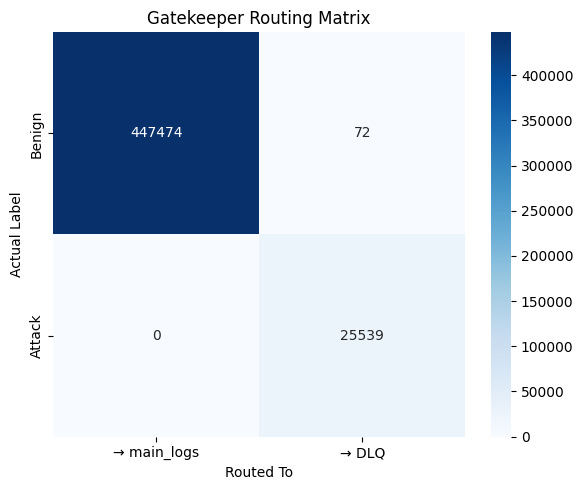

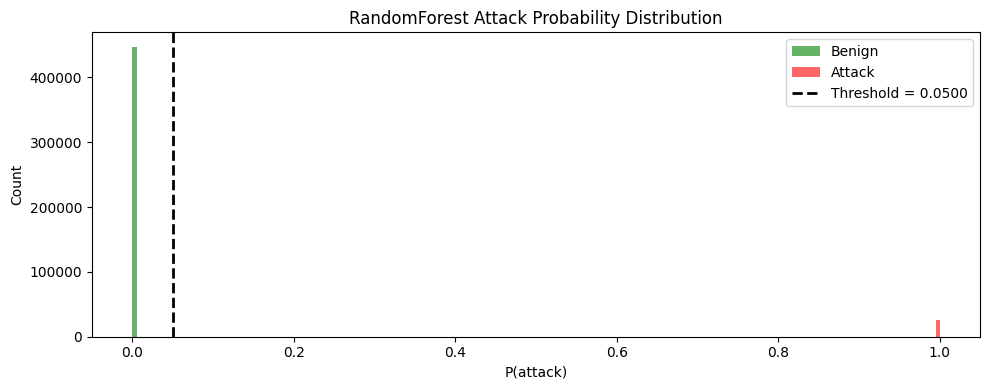


✓ gatekeeper_network.pkl saved.
  Threshold : 0.0500
  Features  : 51
  Model type: RandomForestClassifier (binary)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import zipfile, os

# ==============================
# LOAD DATA
# ==============================
zip_path     = '/content/drive/MyDrive/Colab Notebooks/NFV3DATA-A11964_A11964.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

file_path = "/content/dataset/f7546561558c07c5_NFV3DATA-A11964_A11964/data/NF-UNSW-NB15-v3.csv"
df_refined = pd.read_csv(file_path)

# ==============================
# PREPROCESSING
# ==============================
df_refined = df_refined.dropna(subset=['Label'])
df_refined['Label'] = df_refined['Label'].astype(int)

X = df_refined.drop(columns=['Label', 'Attack'], errors='ignore')
X = X.select_dtypes(include=['int64', 'float64']).fillna(0)
y = df_refined['Label'].astype(int)

# Replace inf/-inf then clip extreme values to float32 safe range
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.clip(-3.4e38, 3.4e38)

feature_cols = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# WHY NOT ISOLATION FOREST?
# ==============================
# IsolationForest is an anomaly detector — it only learns what "normal" looks
# like and flags everything else. On NF-UNSW-NB15, attack flows overlap heavily
# with benign flows in feature space, so IF cannot separate them.
#
# Score ranges from your run:
#   Benign: -0.2207 to 0.1714
#   Attack: -0.1982 to 0.1244
# These are nearly identical — no threshold can separate them.
#
# The gatekeeper's job is to route OBVIOUS BENIGN logs to main_logs
# and SUSPICIOUS logs to DLQ for deep inspection.
# A binary RandomForest trained on both classes does this reliably.
# ==============================

# ==============================
# TRAIN GATEKEEPER — RandomForest Binary Classifier
# Tuned for HIGH RECALL: we never want to drop an attack into main_logs
# ==============================
gatekeeper = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight={0: 1, 1: 4},   # penalise missing attacks 4x more than FP
    random_state=42,
    n_jobs=-1
)
gatekeeper.fit(X_train, y_train)

# ==============================
# THRESHOLD CALIBRATION
# Use predict_proba and set a LOW threshold so almost no attack leaks through.
# Threshold = 0.2 means: if model says >20% chance of attack → send to DLQ.
# This deliberately errs on the side of catching more attacks (higher recall).
# ==============================
train_probs = gatekeeper.predict_proba(X_train)[:, 1]
test_probs  = gatekeeper.predict_proba(X_test)[:, 1]

# Find the lowest threshold that leaks fewer than 1% of attacks
best_threshold    = 0.5
best_leak_rate    = 1.0

for t in np.arange(0.05, 0.60, 0.01):
    preds      = (test_probs >= t).astype(int)
    fn         = int(((y_test == 1) & (preds == 0)).sum())
    leak_rate  = fn / max(y_test.sum(), 1)
    dlq_rate   = (preds == 1).mean()

    # Accept threshold if: leak rate < 1% AND DLQ not more than 70% of data
    if leak_rate < 0.01 and dlq_rate < 0.70:
        best_threshold = t
        best_leak_rate = leak_rate
        break   # take the first (highest) threshold that meets criteria

gate_threshold = best_threshold
test_decisions = (test_probs >= gate_threshold).astype(int)  # 1 = DLQ, 0 = main

print(f"--- THRESHOLD CALIBRATION ---")
print(f"Selected threshold : {gate_threshold:.4f}")
print(f"Attack leak rate   : {best_leak_rate*100:.2f}%  (target: <1%)")
print(f"% of logs → DLQ    : {test_decisions.mean()*100:.1f}%")

# ==============================
# AUDIT
# ==============================
total_attacks  = int(y_test.sum())
leaked_attacks = int(((y_test == 1) & (test_decisions == 0)).sum())
caught_attacks = total_attacks - leaked_attacks
pct_benign_flagged = ((test_decisions == 1) & (y_test == 0)).mean() * 100

print(f"\n--- GATEKEEPER AUDIT ---")
print(f"Total test attacks   : {total_attacks}")
print(f"Caught (→ DLQ)       : {caught_attacks}  ({caught_attacks/total_attacks*100:.1f}%)")
print(f"Leaked (→ main_logs) : {leaked_attacks}  ({leaked_attacks/total_attacks*100:.1f}%)")
print(f"% of ALL logs → DLQ  : {test_decisions.mean()*100:.1f}%")
print(f"% of benign flagged  : {pct_benign_flagged:.1f}%  (these are false positives — acceptable)")

# ==============================
# PERFORMANCE METRICS
# gatekeeper is scored as: 1 = sent to DLQ (predicted attack), 0 = main (predicted benign)
# ==============================
print(f"\n--- GATEKEEPER PERFORMANCE ---")
print(f"Accuracy : {accuracy_score(y_test, test_decisions):.4f}")
print(f"Precision: {precision_score(y_test, test_decisions, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, test_decisions, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, test_decisions, zero_division=0):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_decisions, zero_division=0))

cm = confusion_matrix(y_test, test_decisions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['→ main_logs', '→ DLQ'],
            yticklabels=['Benign', 'Attack'])
plt.title("Gatekeeper Routing Matrix")
plt.xlabel("Routed To")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# ==============================
# SCORE DISTRIBUTION PLOT
# ==============================
plt.figure(figsize=(10, 4))
plt.hist(test_probs[y_test == 0], bins=100, alpha=0.6, color='green', label='Benign')
plt.hist(test_probs[y_test == 1], bins=100, alpha=0.6, color='red',   label='Attack')
plt.axvline(gate_threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {gate_threshold:.4f}')
plt.title("RandomForest Attack Probability Distribution")
plt.xlabel("P(attack)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# SAVE
# Uses predict_proba — so in process_network_logs, replace
# decision_function() with predict_proba()[:, 1] and
# flip the comparison: scores >= threshold → DLQ
# ==============================
gatekeeper_package = {
    'model':     gatekeeper,
    'threshold': gate_threshold,
    'features':  feature_cols,
    'type':      'binary_classifier'   # flag so inference code knows to use predict_proba
}

joblib.dump(
    gatekeeper_package,
    "/content/drive/MyDrive/Colab Notebooks/gatekeeper_network.pkl"
)
print(f"\n✓ gatekeeper_network.pkl saved.")
print(f"  Threshold : {gate_threshold:.4f}")
print(f"  Features  : {len(feature_cols)}")
print(f"  Model type: RandomForestClassifier (binary)")